In [1]:
import requests
import pandas as pd
import time
from tqdm import tqdm #import para la barra

session = requests.Session() #Abre una sesión para consultar a la API en lugar de abrir y cerrar sesion con cada consulta.

BASE_URL = "https://api.deezer.com"
MAX_SONGS = 50  #límite de canciones por artista
SLEEP_TIME = 0.3  #pausa entre consultas para no sobrecargar la API

ARTISTS = [
    "La Fuga",
    "Fito y fitipaldis",
    "Billie Eilish",
    "Love of Lesbian",
    "Estopa",
    "Mägo de Oz",
    "Mr. Kilombo",
    "Rozalén",
    "Taburete",
    "Maná",
    "La Plazuela",
    "Veintiuno",
    "Ojete Calor",
    "Rata Blanca",
    "Vetusta Morla",
    "Leiva",
    "Bad Bunny",
    "Enrique Bunbury",
    "Marea",
    "Joaquín Sabina",
    "Rosalía",
    "Queen",
    "The Lumineers",
    "Foo Fighters",
    "Muse",
    "Metallica",
    "Ginebras",
    "IZAL",
    "Kaiser Chiefs",
    "Residente"
]

def search_tracks(album_id):
    url = f"{BASE_URL}/album/{album_id}/tracks"
    r = session.get(url)
    r.raise_for_status() #evalua el fallo de forma inmediata y clara, si el codigo no es 200 nos salta fallo claro
    data = r.json()
    if not data["data"]: #pese a estar comprobados, si no se encuentran datos, aplicamos este if
        print(f"⚠️ No tracks found for album {album_id}")
        return []
    return data["data"]

def album_data(album_id):
    url = f"{BASE_URL}/album/{album_id}"
    r = session.get(url)
    r.raise_for_status()
    data = r.json()
    return {
    "album_title": data["title"],
    "year": int(data.get("release_date", None)[:4]) if data.get("release_date") else None, #None para que no falle el codigo si no está y [:4] para devolver solo los primeros 4 caracteres (año)
    "genre": data.get("genres", {}).get("data", [{}])[0].get("name", None),
    "genre_id": data.get("genre_id", None)
}

def search_artist(name):
    url = f"{BASE_URL}/search/artist" #define url con una base común para todas incluida en variable BASE_URL y un añadido para esta función
    params = {"q": name, "limit": 1} #diccionario para definir la busqueda, el nombre lo buscaremos desde su clave q(definida por deezer) limite 1 para que solo exporte 1 artista
    r = session.get(url, params=params) #llamar a la url con los parámetros facilitados
    r.raise_for_status()
    data = r.json()
    if not data["data"]:
        print(f"⚠️ Artist not found: {name}")
        return None
    return data["data"][0]

def search_albums(artist_id):
    url = f"{BASE_URL}/artist/{artist_id}/albums" #con la url base y el id obtenido en la función search_artist
    r = session.get(url)
    r.raise_for_status()
    data = r.json()
    if not data["data"]:
        print(f"⚠️ No albums found for artist {artist_id}")
        return []
    return data["data"]

Processing: La Fuga:   0%|          | 0/30 [00:00<?, ?it/s]

Processing: Residente | Album 16 | 7.4s: 100%|██████████| 30/30 [01:21<00:00,  2.71s/it]       


✅ Exported successfully! 1500 tracks from 30 artists

✅ All artists processed successfully


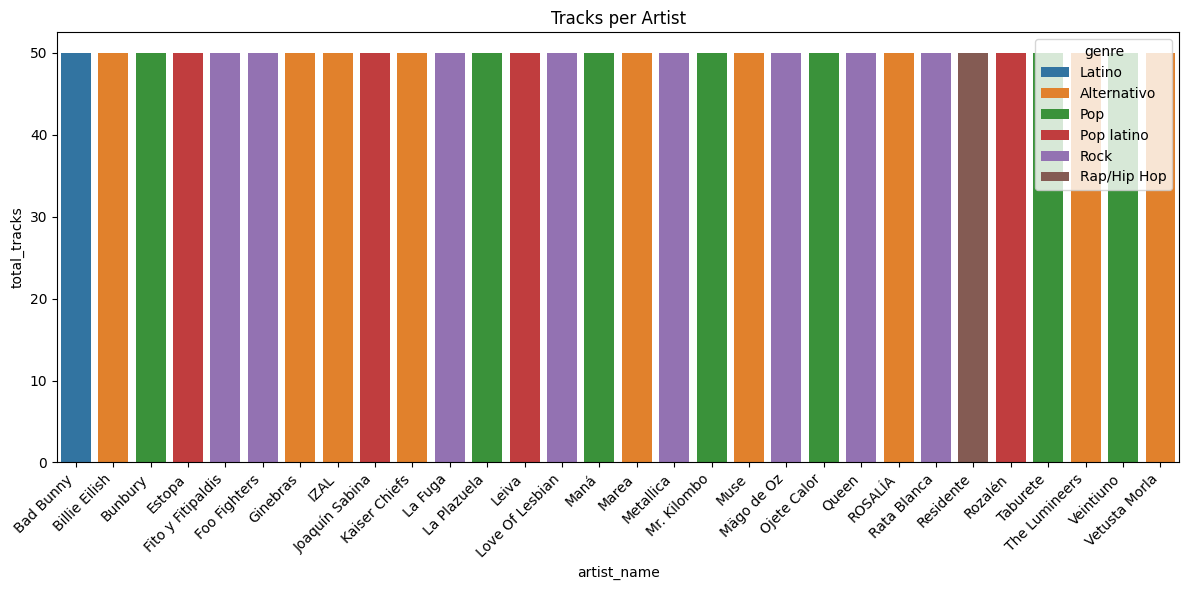

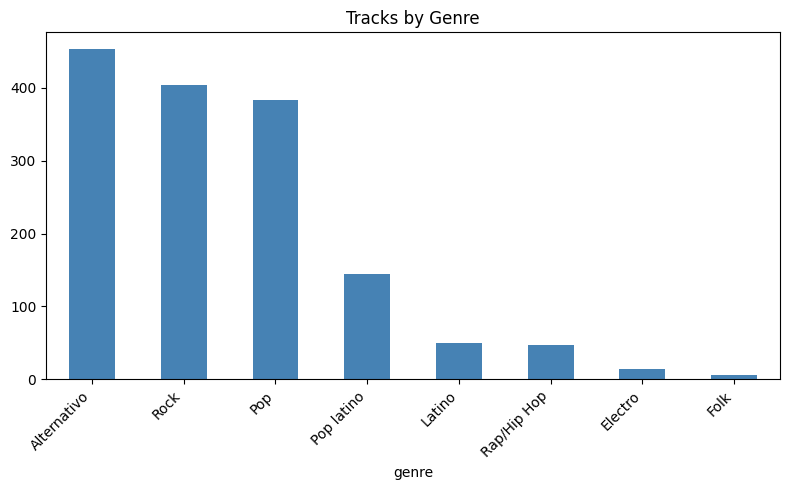

In [2]:
results = []
failed_artists = []  # lista para guardar artistas que fallaron
bar = tqdm(ARTISTS, desc="Starting...")

try: #añadimos este try/finally para cerrar la sesión al final aunque algo falle
    for artist in bar:
        bar.set_description(f"Processing: {artist}")
        try:
            artist_info = search_artist(artist) #buscamos al artista llamando a la función y creamos variable
            if artist_info is None: #si no se encontró, salta al siguiente
                continue
            artist_id = artist_info["id"] #extraemos su id con la variable anterior e indicando la clave que buscamos al ser diccionario
            albums = search_albums(artist_id) #llamamos a la funcion search_albums con el id de artista obtenido en la anterior y creamos variable

            total_songs = 0
            album_count = 0  #contador de álbumes procesados por artista
            artist_start_time = time.time()  # guardamos el tiempo de inicio del artista

            for album in albums:
                if total_songs >= MAX_SONGS:
                    break
                album_id = album["id"]
                tracks = search_tracks(album_id)
                if not tracks:
                    continue
                album_count += 1  #incrementamos el contador de álbumes
                bar.set_description(f"Processing: {artist} | Album {album_count}") #actualizamos la barra con el álbum actual
                total_songs += len(tracks) #contamos ANTES de procesar
                if total_songs > MAX_SONGS: #cortamos si nos pasamos
                    tracks = tracks[:MAX_SONGS - (total_songs - len(tracks))]
                info_album = album_data(album_id) #extraemos los datos del album
                time.sleep(SLEEP_TIME) #como deezer tiene un max de llamadas por seg, hacemos que python haga una pausa para no sobrecargar la API

                for track in tracks:
                    results.append({
                        "artist_id": artist_info["id"],
                        "artist_name": artist_info["name"],
                        "album_title": info_album["album_title"],
                        "track_title": track["title"],
                        "type": track["type"],
                        "year": info_album["year"],
                        "genre": info_album["genre"],
                        "genre_id": info_album["genre_id"]
                    })
                
            artist_time = round(time.time() - artist_start_time, 2)  # calculamos el tiempo transcurrido
            bar.set_description(f"Processing: {artist} | Album {album_count} | {artist_time}s")  # mostramos en la barra
        except requests.exceptions.RequestException as e:
            print(f"⚠️ Network error processing {artist}: {e}")
            failed_artists.append(artist) #guardamos el artista fallido
            continue

    df = pd.DataFrame(results) #pasar a tabla

    df.to_csv("deezer_artists.csv", index=False, encoding="utf-8-sig")
    #Convierte la tabla a CSV, guárdala con ese nombre, sin la columna de índices y con soporte para caracteres especiales del español
    print(f"✅ Exported successfully! {len(df)} tracks from {df['artist_name'].nunique()} artists")

    if failed_artists:
        print(f"\n⚠️ {len(failed_artists)} artists failed: {', '.join(failed_artists)}")
    else:
        print("\n✅ All artists processed successfully")

    df.head()
finally:
    session.close() #cerramos la sesión una vez terminado todo


import matplotlib.pyplot as plt  #librería para crear gráficas
import seaborn as sns  #librería para gráficas más visuales, construida sobre matplotlib

# preparamos los datos agrupados por artista
df_artists = df.groupby("artist_name").agg(  #agrupamos por artista
    total_tracks=("track_title", "count"),  #contamos el total de canciones por artista
    genre=("genre", "first")  #cogemos el primer género asociado al artista
).reset_index().sort_values("total_tracks", ascending=False)  #reiniciamos el índice y ordenamos de más a menos canciones

# gráfica 1 - canciones por artista
plt.figure(figsize=(12, 6))  #tamaño de la figura en pulgadas (ancho x alto)
sns.barplot(data=df_artists, x="artist_name", y="total_tracks", hue="genre")  #barras por artista coloreadas por género
plt.title("Tracks per Artist")  #título de la gráfica
plt.xticks(rotation=45, ha="right")  #rotamos los nombres del eje x para que no se solapen
plt.tight_layout()  #ajusta automáticamente los márgenes para que no se corten etiquetas
plt.show()  #muestra la gráfica

# gráfica 2 - distribución por género
plt.figure(figsize=(8, 5))  #tamaño de la figura
df.groupby("genre")["track_title"].count().sort_values(ascending=False).plot(kind="bar", color="steelblue")  #agrupamos por género y contamos canciones
plt.title("Tracks by Genre")  #título de la gráfica
plt.xticks(rotation=45, ha="right")  #rotamos los nombres del eje x
plt.tight_layout()  #ajusta los márgenes
plt.show()  #muestra la gráfica

In [3]:
# Tabla formateada con colores
df = pd.read_csv("deezer_artists.csv")
df.head(10).style \
    .set_caption("🎵 Deezer Artists Data") \
    .set_properties(**{"text-align": "left", "font-size": "12px"})

,artist_id,artist_name,album_title,track_title,type,year,genre,genre_id
0,10786,La Fuga,Justo Después Del Silencio,Este Blues,track,2025,Rock,152
1,10786,La Fuga,Justo Después Del Silencio,Cuántos Años,track,2025,Rock,152
2,10786,La Fuga,Justo Después Del Silencio,Horas Infinitas,track,2025,Rock,152
3,10786,La Fuga,Justo Después Del Silencio,A Ratos,track,2025,Rock,152
4,10786,La Fuga,Justo Después Del Silencio,Flores de Mentira,track,2025,Rock,152
5,10786,La Fuga,Justo Después Del Silencio,Por Echarte De Menos,track,2025,Rock,152
6,10786,La Fuga,Justo Después Del Silencio,Mil Perdones,track,2025,Rock,152
7,10786,La Fuga,Justo Después Del Silencio,En Mi Pecho,track,2025,Rock,152
8,10786,La Fuga,Justo Después Del Silencio,Demasiado Tarde,track,2025,Rock,152
9,10786,La Fuga,Justo Después Del Silencio,Luna,track,2025,Rock,152
